In [1]:
import os
import random
import warnings
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchmetrics

# Robust Audio Library
import librosa

warnings.filterwarnings('ignore')

# Config
SR = 16000
DURATION = 1.0
BATCH_SIZE = 128
EPOCHS = 200
LR = 5e-5 # Lower LR for Fine-Tuning
PATIENCE = 10

# Seeding
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device Logic Debugging
print("="*30)
print(f"PyTorch Version: {torch.__version__}")

DEVICE = torch.device('cpu') # Default

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    DEVICE = torch.device('xpu:0') # Explicitly target XPU:0
    print("XPU Detected!")
    print(f"XPU Name: {torch.xpu.get_device_name(0)}")
    print(f"XPU Count: {torch.xpu.device_count()}")
else:
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        print("XPU NOT DETECTED. Using CUDA.")
    else:
        print("NO ACCELERATOR DETECTED. Falling back to CPU.")

print(f"Active Device for Training: {DEVICE}")
print("="*30)

PyTorch Version: 2.9.1+xpu
XPU Detected!
XPU Name: Intel(R) Arc(TM) A750 Graphics
XPU Count: 1
Active Device for Training: xpu:0


In [2]:
class AudioDataset(Dataset):
    def __init__(self, files, class_map):
        self.files = files
        self.class_map = class_map
        self.n_samples = int(SR * DURATION)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.class_map[os.path.basename(os.path.dirname(path))]
        
        try:
            sig, _ = librosa.load(path, sr=SR, duration=DURATION)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            sig = np.zeros(self.n_samples)
            
        if len(sig) < self.n_samples:
            sig = np.pad(sig, (0, self.n_samples - len(sig)))
        else:
            sig = sig[:self.n_samples]
            
        mel = librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
        
        spec = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)
        
        return spec, label

In [3]:
data_path = Path('dataset')
classes = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
class_map = {c:i for i,c in enumerate(classes)}
files = sorted(glob(str(data_path / "*" / "*.wav")))
random.shuffle(files)

s1, s2 = int(0.8 * len(files)), int(0.9 * len(files))
args = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

train_loader = DataLoader(AudioDataset(files[:s1], class_map), shuffle=True, **args)
val_loader = DataLoader(AudioDataset(files[s1:s2], class_map), shuffle=False, **args)
test_loader = DataLoader(AudioDataset(files[s2:], class_map), shuffle=False, **args)

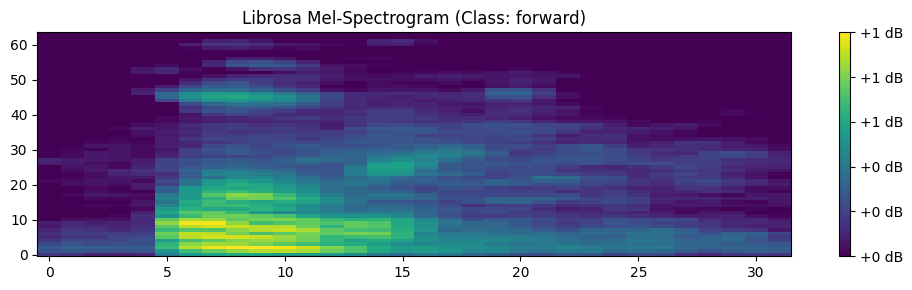

In [4]:
def plot_sample(dataset):
    spec, label = dataset[random.randint(0, len(dataset)-1)]
    plt.figure(figsize=(10, 3))
    plt.imshow(spec[0].numpy(), origin='lower', aspect='auto', cmap='viridis')
    plt.title(f'Librosa Mel-Spectrogram (Class: {classes[label]})')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

try:
    plot_sample(AudioDataset(files[:s1], class_map))
except Exception as e:
    print(f"Could not plot sample: {e}")

In [5]:
def create_model(n_classes):
    model = models.resnet34(weights='DEFAULT')
    
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(memory_format=torch.channels_last).to(DEVICE)

def run_epoch(model, loader, optimizer, metric, train=True):
    model.train() if train else model.eval()
    loss_avg = torchmetrics.MeanMetric().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    ctx = torch.autocast(DEVICE.type, dtype=torch.bfloat16, enabled=True) if DEVICE.type != 'cpu' else torch.autocast('cpu', dtype=torch.bfloat16, enabled=True)

    for x, y in loader:
        x, y = x.to(DEVICE, memory_format=torch.channels_last), y.to(DEVICE)
        with torch.enable_grad() if train else torch.no_grad():
            with ctx:
                out = model(x)
                loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        loss_avg.update(loss)
        metric.update(out, y)
    return loss_avg.compute().item(), metric.compute().item()

In [6]:
model = create_model(len(classes))
print(f"Model created and moved to {DEVICE} (Unfrozen)")

optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
acc = torchmetrics.Accuracy(task="multiclass", num_classes=len(classes)).to(DEVICE)

# History for plotting
history = {'train_acc': [], 'val_acc': [], 'val_loss': []}

best_loss = float('inf')
patience_counter = 0

print("Training...")
for epoch in range(EPOCHS):
    run_epoch(model, train_loader, optimizer, acc, train=True)
    tl, ta = 0, acc.compute().item()
    acc.reset()
    
    vl, va = run_epoch(model, val_loader, optimizer, acc, train=False)
    acc.reset()
    scheduler.step()
    
    # Append stats
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['val_loss'].append(vl)
    
    print(f"Ep {epoch+1} | Acc: {ta:.3f} | Val: {va:.3f} | V_Loss: {vl:.4f}")

    if vl < best_loss:
        best_loss = vl
        patience_counter = 0
        torch.save(model.state_dict(), 'best.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE: print("Stopped."); break

Model created and moved to xpu:0 (Unfrozen)
Training...
Ep 1 | Acc: 0.610 | Val: 0.853 | V_Loss: 0.4268
Ep 2 | Acc: 0.909 | Val: 0.912 | V_Loss: 0.2632
Ep 3 | Acc: 0.959 | Val: 0.922 | V_Loss: 0.2410
Ep 4 | Acc: 0.980 | Val: 0.925 | V_Loss: 0.2433
Ep 5 | Acc: 0.990 | Val: 0.926 | V_Loss: 0.2503
Ep 6 | Acc: 0.994 | Val: 0.930 | V_Loss: 0.2580
Ep 7 | Acc: 0.995 | Val: 0.932 | V_Loss: 0.2582
Ep 8 | Acc: 0.994 | Val: 0.929 | V_Loss: 0.2949
Ep 9 | Acc: 0.992 | Val: 0.936 | V_Loss: 0.2696
Ep 10 | Acc: 0.995 | Val: 0.932 | V_Loss: 0.2826
Ep 11 | Acc: 0.995 | Val: 0.934 | V_Loss: 0.2606
Ep 12 | Acc: 0.997 | Val: 0.936 | V_Loss: 0.2682
Ep 13 | Acc: 0.997 | Val: 0.938 | V_Loss: 0.2893
Stopped.


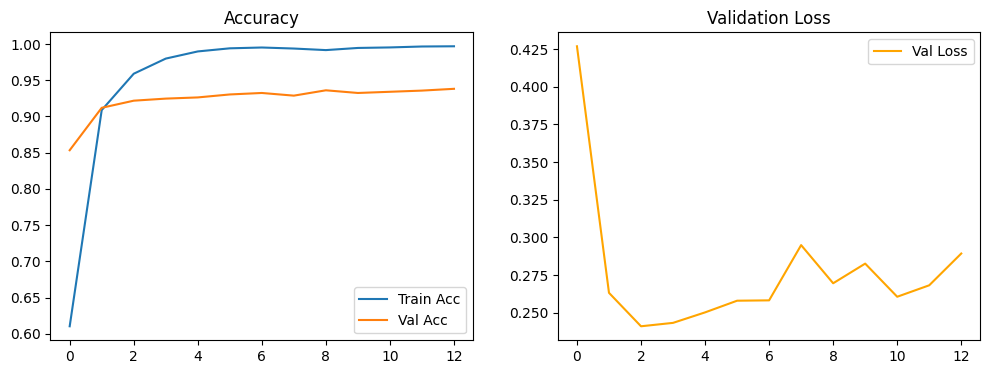

In [7]:
# Plotting Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.legend()
plt.title('Validation Loss')
plt.show()

Test Accuracy: 0.9308


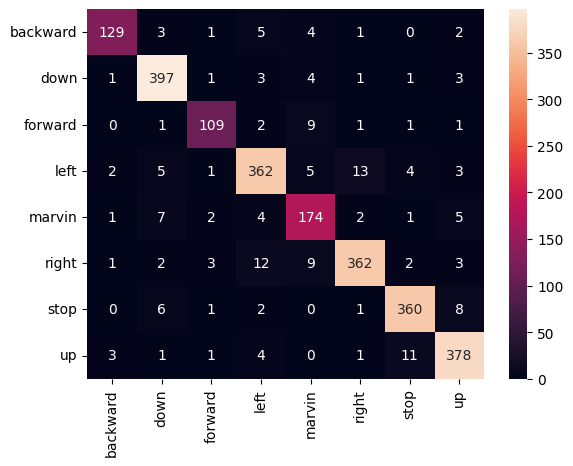

In [8]:
# Eval
if os.path.exists('best.pth'):
    model.load_state_dict(torch.load('best.pth'))
    _, test_acc = run_epoch(model, test_loader, optimizer, acc, train=False)
    print(f"Test Accuracy: {test_acc:.4f}")

    preds, targs = [], []
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).argmax(1).cpu())
            targs.append(y.cpu())

    sns.heatmap(confusion_matrix(torch.cat(targs), torch.cat(preds)), annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.show()